# kNN Geometric Interpretations

In [ ]:
import numpy as np
import scipy.spatial
import matplotlib.pylab as plt
from scipy import interpolate
from matplotlib import gridspec

boxsize = 1000.

pos = np.random.rand(25,2)*boxsize
ones = np.ones_like(pos)
pos = boxsize*0.5*ones + pos
pos = pos % boxsize

In [ ]:
kNN = [1,2,3,4,5,6,7]
nrandoms = 400**2

xtree = scipy.spatial.cKDTree(pos, boxsize=boxsize)

# random_pos = np.random.rand(nrandoms, 2)*boxsize
n_per_axis = 2500
x = np.linspace(0, boxsize, n_per_axis, endpoint=False)
y = np.linspace(0, boxsize, n_per_axis, endpoint=False)
xx, yy = np.meshgrid(x, y)
random_pos = np.vstack([xx.ravel(), yy.ravel()]).T  # shape: (n_per_axis*n_per_axis, 2)

vol, disi = xtree.query(random_pos, k=kNN)

r_check = 80

mask = np.where((vol[:,0]<r_check))
cdf1nn = random_pos[mask]
mask = np.where((vol[:,1]<r_check))
cdf2nn = random_pos[mask]
mask = np.where((vol[:,2]<r_check))
cdf3nn = random_pos[mask]
mask = np.where((vol[:,3]<r_check))
cdf4nn = random_pos[mask]
mask = np.where((vol[:,4]<r_check))
cdf5nn = random_pos[mask]
mask = np.where((vol[:,5]<r_check))
cdf6nn = random_pos[mask]
mask = np.where((vol[:,6]<r_check))
cdf7nn = random_pos[mask]

mask = np.where((vol[:,0]>r_check-2) & (vol[:,0]<r_check+2))
area1nn = random_pos[mask]

cdf4nn, cdf5nn, cdf6nn, cdf7nn

(array([], shape=(0, 2), dtype=float64),
 array([], shape=(0, 2), dtype=float64),
 array([], shape=(0, 2), dtype=float64),
 array([], shape=(0, 2), dtype=float64))

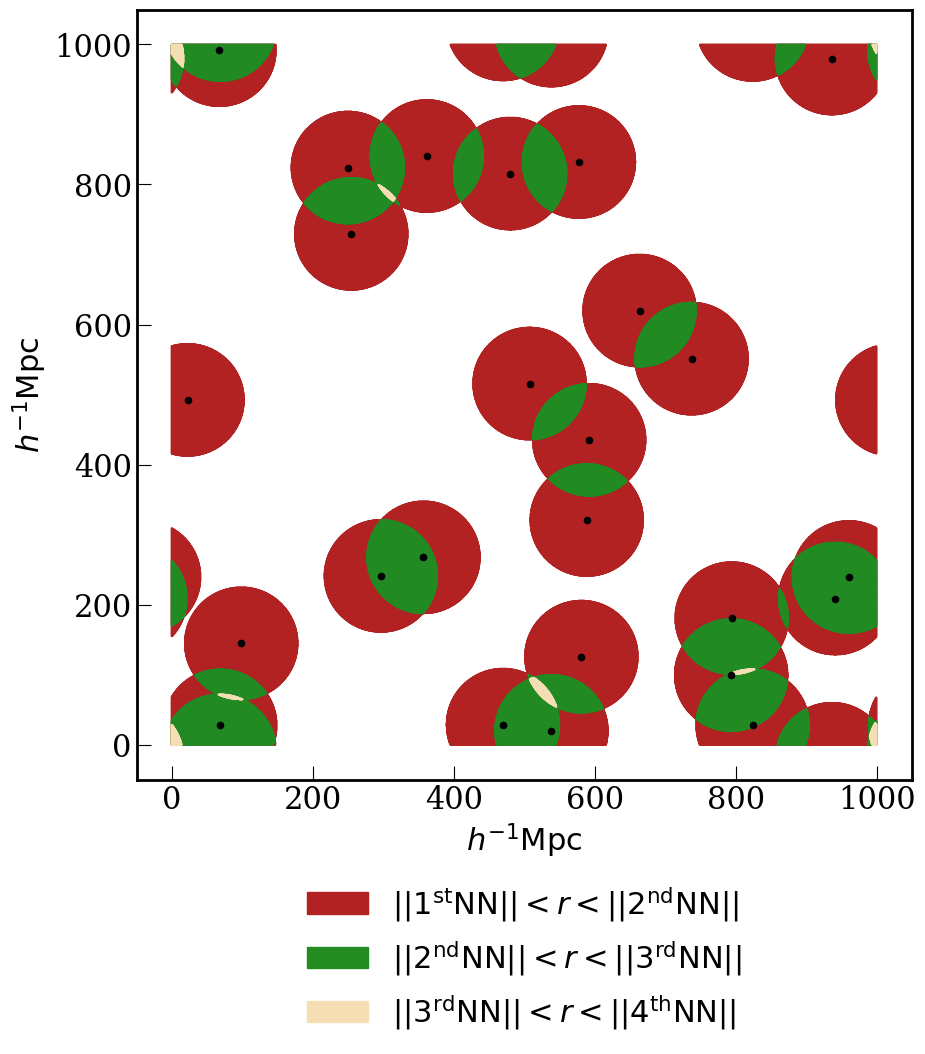

In [ ]:
from matplotlib import gridspec
import matplotlib.patches as mpatches
plt.figure(figsize=(10,10))
plt.rcParams["axes.linewidth"]  = 2.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [7, 7]
plt.rcParams['font.family']="serif"
plt.rc("text", usetex=False)
plt.rc("font", size=22)


plt.scatter(cdf1nn[:,0],cdf1nn[:,1], s= 2, facecolor = 'firebrick',edgecolor='none', alpha=0.7)
plt.scatter(cdf2nn[:,0],cdf2nn[:,1], s= 2, facecolor = 'forestgreen',edgecolor='none', alpha=0.7)
plt.scatter(cdf3nn[:,0],cdf3nn[:,1], s= 2, facecolor = 'wheat',edgecolor='none', alpha=1)
plt.scatter(cdf4nn[:,0],cdf4nn[:,1], s= 5, facecolor = 'darkgreen',edgecolor='none', alpha=0.7)


plt.scatter(pos[:,0],pos[:,1], marker='o', s= 20.0, color = 'k')
# Customize legend appearance


legend_patches = [
    mpatches.Patch(color='firebrick', alpha=1, label=r'$||1^{\mathrm{st}} \mathrm{NN}|| < r < ||2^{\mathrm{nd}} \mathrm{NN}||$'),
    mpatches.Patch(color='forestgreen', alpha=1, label=r'$||2^{\mathrm{nd}} \mathrm{NN}|| < r < ||3^{\mathrm{rd}} \mathrm{NN}||$'),
    mpatches.Patch(color='wheat', alpha=1, label=r'$||3^{\mathrm{rd}} \mathrm{NN}|| < r < ||4^{\mathrm{th}} \mathrm{NN}||$')
  #  ,mpatches.Patch(color='darkgreen', alpha=0.7, label=r'$||4^{\mathrm{th}} \mathrm{NN}|| < r ||5^{\mathrm{th}} \mathrm{NN}||$')
]

# plt.legend(handles=legend_patches)



plt.xlabel(r"$h^{-1} \mathrm{Mpc}$")
plt.ylabel(r"$h^{-1} \mathrm{Mpc}$", rotation=90)
plt.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.1))

In [ ]:
pos1 = np.random.rand(35,2)*boxsize
pos2 = np.random.rand(40,2)*boxsize

In [ ]:
kNN1 = [1]
kNN2 = [1]
nrandoms = 1000**2
r_check = 80
xtree1 = scipy.spatial.cKDTree(pos1, boxsize=boxsize)
xtree2 = scipy.spatial.cKDTree(pos2, boxsize=boxsize)

#Generate  nrandoms randoms on the same volume
# random_pos = np.random.rand(nrandoms, 2)*boxsize
n_per_axis = 3500
x = np.linspace(0, boxsize, n_per_axis, endpoint=False)
y = np.linspace(0, boxsize, n_per_axis, endpoint=False)
xx, yy = np.meshgrid(x, y)
random_pos = np.vstack([xx.ravel(), yy.ravel()]).T  # shape: (n_per_axis*n_per_axis, 2)

vol1, disi1 = xtree1.query(random_pos, k=kNN1)
vol2, disi2 = xtree2.query(random_pos, k=kNN2)

mask = np.where((vol1[:,0]<r_check))
type1_1nn = random_pos[mask]
mask = np.where((vol2[:,0]<r_check))
type2_1nn = random_pos[mask]
mask = np.where((vol1[:,0]<r_check)*(vol2[:,0]<r_check))
common_1nn = random_pos[mask]

/tmp/ipykernel_536/3382559626.py:21: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(pos2[:,0],pos2[:,1], marker='x', s= 100.0, facecolor = 'black',edgecolor='none')


Text(0, 0.5, '$h^{-1} \\mathrm{Mpc}$')

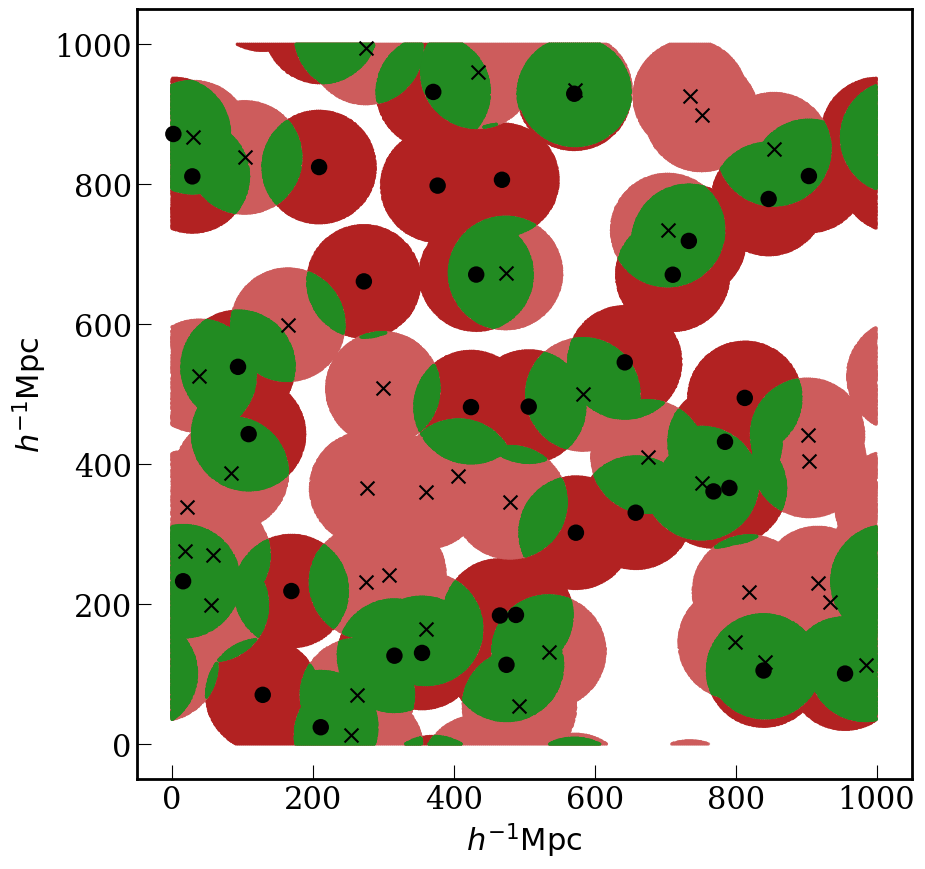

In [ ]:
from matplotlib import gridspec
plt.figure(figsize=(10,10))
plt.rcParams["axes.linewidth"]  = 2.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [7, 7]
plt.rcParams['font.family']="serif"
plt.rc("text", usetex=False)
plt.rc("font", size=22)

plt.scatter(type1_1nn[::10,0],type1_1nn[::10,1], s= 5, facecolor = 'firebrick',edgecolor='none', alpha=0.7)
plt.scatter(type2_1nn[::10,0],type2_1nn[::10,1], s= 5, facecolor = 'indianred',edgecolor='none', alpha=0.7)
plt.scatter(common_1nn[::10,0],common_1nn[::10,1], s= 5, facecolor = 'forestgreen',edgecolor='none', alpha=1)

plt.scatter(pos1[:,0],pos1[:,1], marker='o', s= 140.0, facecolor = 'black',edgecolor='none')
plt.scatter(pos2[:,0],pos2[:,1], marker='x', s= 100.0, facecolor = 'black',edgecolor='none')

plt.xlabel(r"$h^{-1} \mathrm{Mpc}$")
plt.ylabel(r"$h^{-1} \mathrm{Mpc}$", rotation=90)

In [ ]:
kNN1 = [2]
kNN2 = [3]
nrandoms = 1000**2
r_check = 80
xtree1 = scipy.spatial.cKDTree(pos1, boxsize=boxsize)
xtree2 = scipy.spatial.cKDTree(pos2, boxsize=boxsize)

#Generate  nrandoms randoms on the same volume
# random_pos = np.random.rand(nrandoms, 2)*boxsize
n_per_axis = 3500
x = np.linspace(0, boxsize, n_per_axis, endpoint=False)
y = np.linspace(0, boxsize, n_per_axis, endpoint=False)
xx, yy = np.meshgrid(x, y)
random_pos = np.vstack([xx.ravel(), yy.ravel()]).T  # shape: (n_per_axis*n_per_axis, 2)

vol1, disi1 = xtree1.query(random_pos, k=kNN1)
vol2, disi2 = xtree2.query(random_pos, k=kNN2)

mask = np.where((vol1[:,0]<r_check))
type1_1nn = random_pos[mask]
mask = np.where((vol2[:,0]<r_check))
type2_1nn = random_pos[mask]
mask = np.where((vol1[:,0]<r_check)*(vol2[:,0]<r_check))
common_1nn = random_pos[mask]

/tmp/ipykernel_536/2396720493.py:21: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(pos2[:,0],pos2[:,1], marker='x', s= 100.0, facecolor = 'k',edgecolor='none')


Text(0, 0.5, '$h^{-1} \\mathrm{Mpc}$')

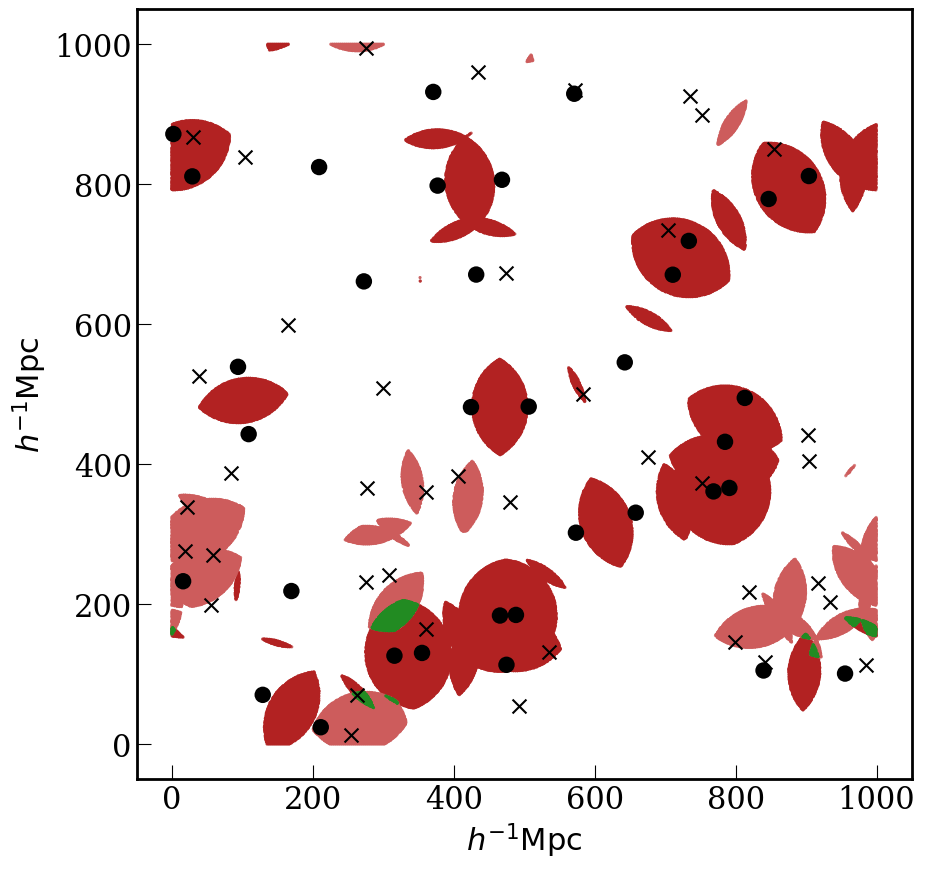

In [ ]:
from matplotlib import gridspec
plt.figure(figsize=(10,10))
plt.rcParams["axes.linewidth"]  = 2.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [7, 7]
plt.rcParams['font.family']="serif"
plt.rc("text", usetex=False)
plt.rc("font", size=22)

plt.scatter(type1_1nn[::10,0],type1_1nn[::10,1], s= 5, facecolor = 'firebrick',edgecolor='none', alpha=0.7)
plt.scatter(type2_1nn[::10,0],type2_1nn[::10,1], s= 5, facecolor = 'indianred',edgecolor='none', alpha=0.7)
plt.scatter(common_1nn[::10,0],common_1nn[::10,1], s= 5, facecolor = 'forestgreen',edgecolor='none', alpha=1)

plt.scatter(pos1[:,0],pos1[:,1], marker='o', s= 140.0, facecolor = 'k',edgecolor='none')
plt.scatter(pos2[:,0],pos2[:,1], marker='x', s= 100.0, facecolor = 'k',edgecolor='none')

plt.xlabel(r"$h^{-1} \mathrm{Mpc}$")
plt.ylabel(r"$h^{-1} \mathrm{Mpc}$", rotation=90)